# 3.1 Burgers' equation

## Environment configuration

CPU: 13th Gen Intel(R) Core(TM) i7-13700K 64GB

python==3.13.9 torch==2.9.1

In [1]:
import torch
from cibsde import nn, utils
import matplotlib.pyplot as plt
device = 'cpu'
seed = 666
torch.manual_seed(seed)

## Parameter settings

In [2]:
# model parameters
d = 1
t = torch.tensor([0.25,0.5,0.75,1],device=device)
D = torch.tensor(0.01 / torch.pi,device=device)
N = [25,50,75,100]
# training parameters
epoch = 10**4
batch = 512
lr = 1e-3
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

## Model initialization

In [3]:
def data_gen(batch):
    return torch.rand([batch,1],device=device) * 2 - 1

def pc0(i,x):
    if i < N[0]:
        return torch.zeros_like(x)
    else:
        return -torch.sin(torch.pi*x)

def pc1(i,x):
    if i < N[1]:
        return torch.zeros_like(x)
    else:
        return -torch.sin(torch.pi*x)
    
def pc2(i,x):
    if i < N[2]:
        return torch.zeros_like(x)
    else:
        return -torch.sin(torch.pi*x)
    
def pc3(i,x):
    if i < N[3]:
        return torch.zeros_like(x)
    else:
        return -torch.sin(torch.pi*x)
    
pc = [pc0,pc1,pc2,pc3]

def h(t,xb):
    return torch.zeros([batch,1],device=device)

def refb(x):
    return x, x, torch.zeros(batch,device=device).bool()

def hitb(x):
    hit = (x[:,0] <= -1)*(x[:,0] >= 1)
    return hit

def f(t,xt,p,grad_p):
    return -p*grad_p

def mu(t,xt):
    return torch.zeros([batch,d],device=device)

def sigma(t,xt):
    return torch.eye(d,device=device).expand([batch,d,d]).clone()*torch.sqrt(2*D)

models = [nn.BoundaryIBSDE(
    d = d,
    t = t[i],
    f = f,
    mu = mu,
    sigma = sigma,
    h = h,
    pc = pc[i],
    data_gen = data_gen,
    N = N[i],
    refb = refb,
    hitb = hitb,
    param = False
).to(device) for i in range(4)]

## Model training

In [4]:
loss_values = [nn.train(
    model,
    train_params
) for model in models]

100%|██████████| 10000/10000 [04:48<00:00, 34.70it/s, loss=9.552413e-05]



Training has been completed.


100%|██████████| 10000/10000 [10:12<00:00, 16.32it/s, loss=1.506029e-04]



Training has been completed.


100%|██████████| 10000/10000 [13:38<00:00, 12.22it/s, loss=9.018097e-04]



Training has been completed.


100%|██████████| 10000/10000 [15:25<00:00, 10.81it/s, loss=8.911405e-04]


Training has been completed.


## PINN

In [5]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.p = utils.FNN(2,1)
    
    def forward(self, batch):
        x = torch.rand([batch,1],requires_grad=True,device=device)*2 - 1
        t = torch.rand([batch,1],requires_grad=True,device=device)
        xb = torch.sign(torch.randn([batch,1],device=device))
        tb = torch.rand([batch,1],device=device)
        xT = torch.rand([batch,1],requires_grad=True,device=device)*2 - 1
        T = torch.ones([batch,1],device=device)
        u = self.p(torch.cat([t,x],dim=1))
        grad_u = torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        grad2_u = torch.autograd.grad(grad_u,x,torch.ones_like(grad_u),retain_graph=True,create_graph=True)[0]
        ut = torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        ub = self.p(torch.cat([tb,xb],dim=1))
        uT = self.p(torch.cat([T,xT],dim=1))
        return torch.cat([ut,ub,uT]), torch.cat([u*grad_u-D*grad2_u,torch.zeros_like(ub,device=device),pc[-1](100,xT)])

## PINN initialization

In [6]:
pinn = PINN().to(device)

## PINN training

In [7]:
loss_value_pinn = nn.train(
    pinn,
    train_params
)

100%|██████████| 10000/10000 [00:56<00:00, 178.05it/s, loss=1.824564e-03]


Training has been completed.


## Loading reference solution

In [8]:
y_rel = torch.load('./datasets/example1.pth')

## Plot figures

In [9]:
x = torch.linspace(-1,1,501)
tt = torch.ones([4,501,1]) * (1-t[:,None,None].cpu())
y_pinn = [pinn.p(torch.cat([tt[i],x[:,None]],dim=1).to(device))[:,0].cpu().detach() for i in range(4)]
y_pre = [model.p(x.to(device)[:,None])[:,0].cpu().detach() for model in models]

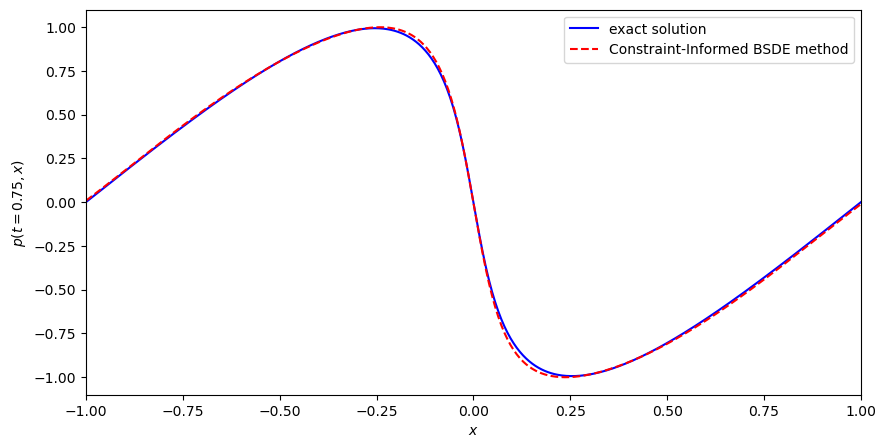

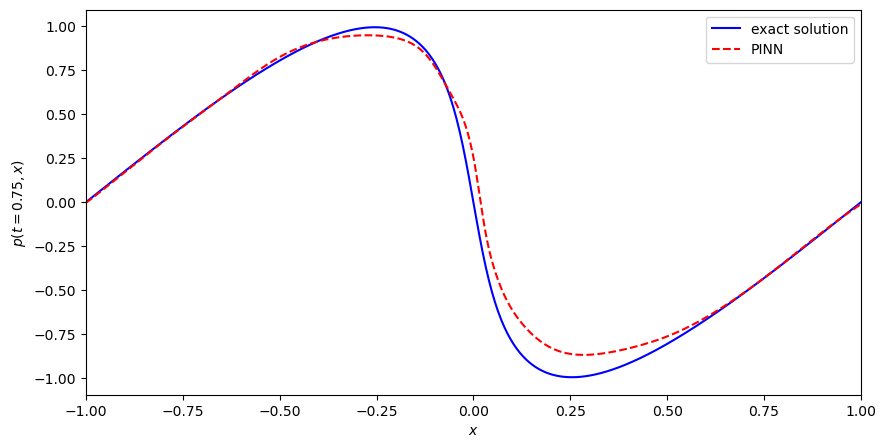

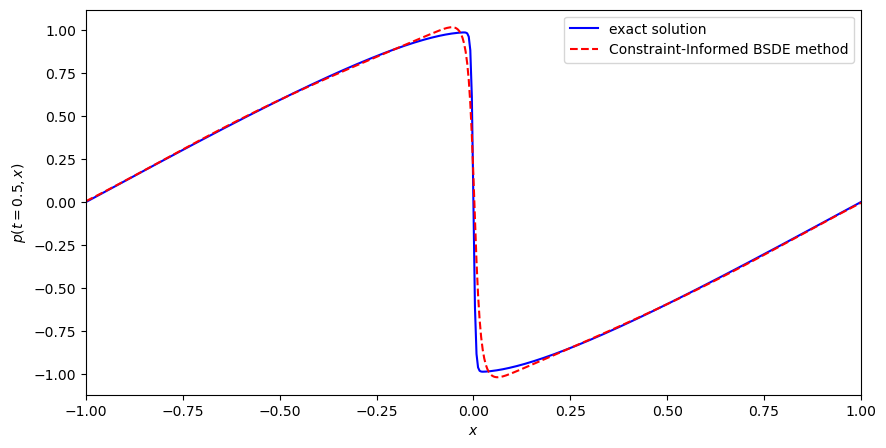

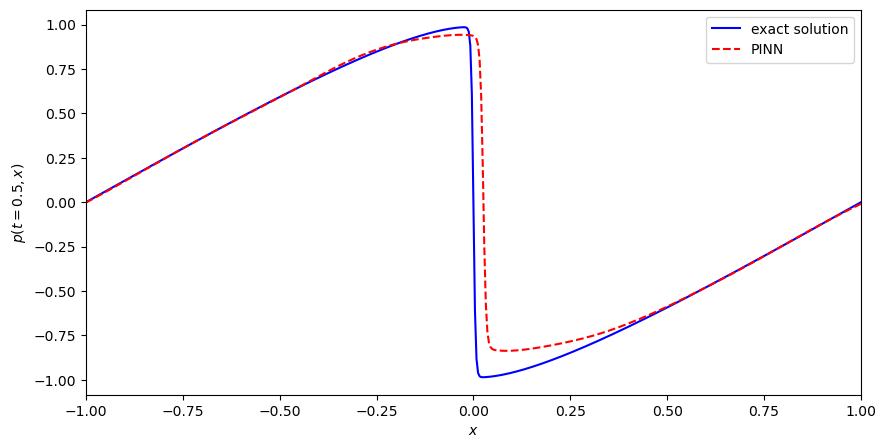

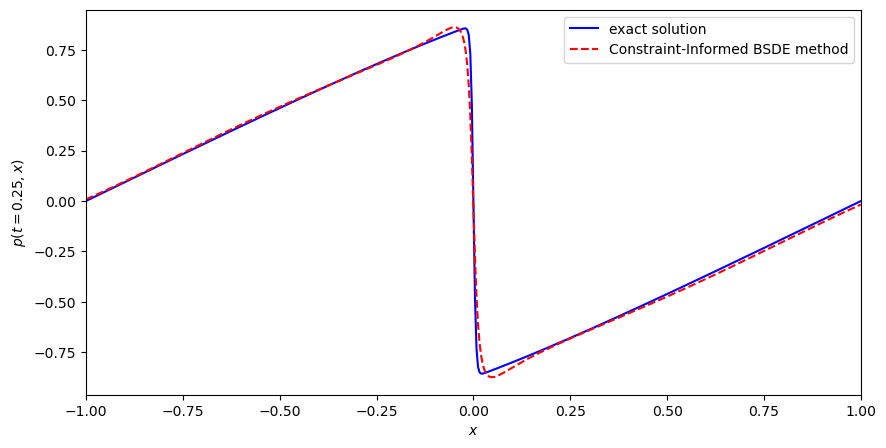

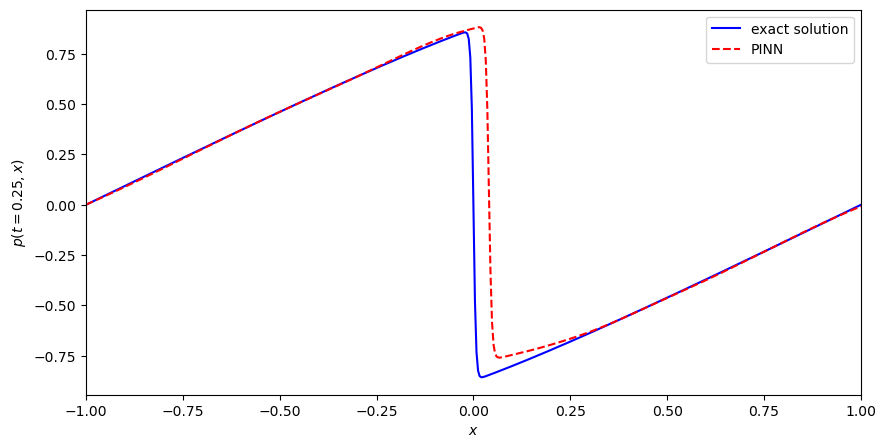

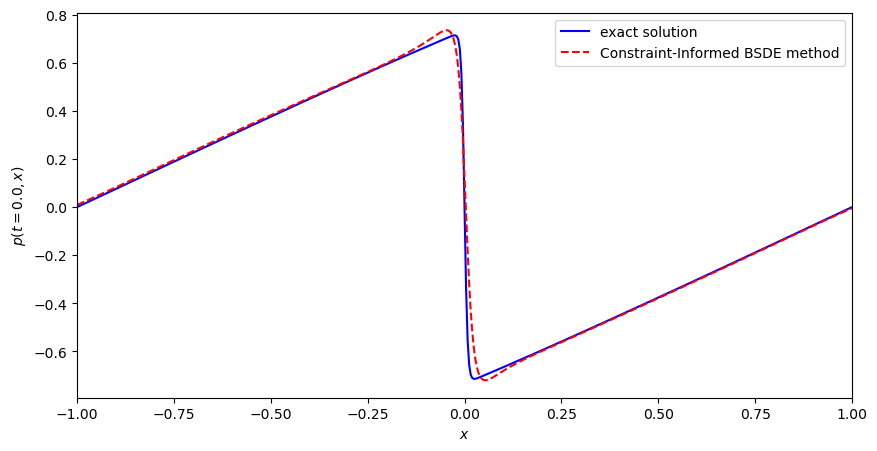

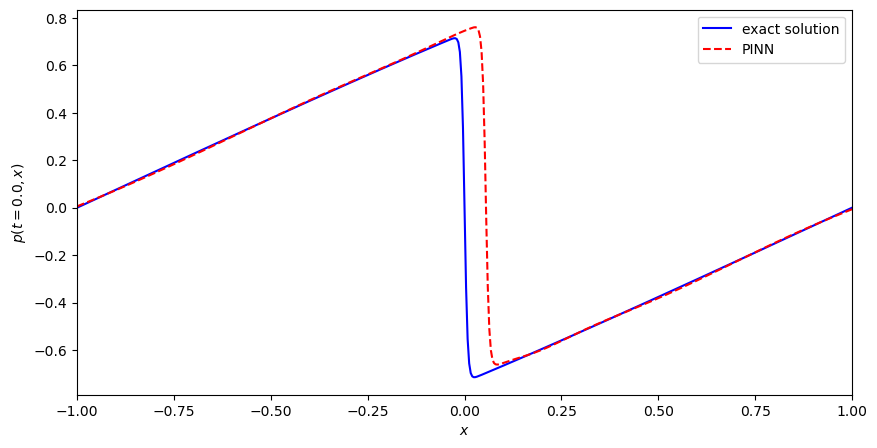

In [10]:
for i in range(4):
    plt.figure(figsize=(10,5))
    plt.xlabel('$x$')
    plt.ylabel('$p(t={},x)$'.format(1-t[i]))
    plt.plot(x, y_rel[i], c='b', label='exact solution')
    plt.plot(x, y_pre[i], c='r', linestyle='--', label='Constraint-Informed BSDE method')
    plt.xlim((-1,1))
    plt.legend()
    plt.savefig('./figures/burger'+str(i+1)+'_cibsde.pdf',format='pdf',dpi=2000)
    plt.show()
    plt.figure(figsize=(10,5))
    plt.xlabel('$x$')
    plt.ylabel('$p(t={},x)$'.format(1-t[i]))
    plt.plot(x, y_rel[i], c='b', label='exact solution')
    plt.plot(x,y_pinn[i],c='r',linestyle='--', label='PINN')
    plt.xlim((-1,1))
    plt.legend()
    plt.savefig('./figures/burger'+str(i+1)+'_pinn.pdf',format='pdf',dpi=2000)
    plt.show()

## Relative L2 errors

In [11]:
error_pinn = []
error_cibsde = []
for i in range(4):
    error_pinn.append(torch.sqrt(((y_pinn[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
    error_cibsde.append(torch.sqrt(((y_pre[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
print('Relative L2 errors \n', 'PINN: ', error_pinn, '\n', 'Ours: ', error_cibsde)

Relative L2 errors 
 PINN:  [tensor(0.1112), tensor(0.3034), tensor(0.4384), tensor(0.5314)] 
 Ours:  [tensor(0.0171), tensor(0.0772), tensor(0.0628), tensor(0.0819)]
